# Experiment 1: Skill Frequency in Data Science Job Postings

Core skills such as Python, SQL, and statistics will have the highest frequency across job postings, indicating baseline requirements for data science roles -- does it supports by the real world data? 

This notebook tests the hypothesis that core skills such as Python, SQL, and statistics appear most frequently across data science job postings.


In [1]:
!pip install pandas
!pip install matplotlib



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
data_path = Path("data/glassdoor_jobs.csv")
df = pd.read_csv(data_path)

required_column = "Job Description"
if required_column not in df.columns:
    raise ValueError(f"Expected '{required_column}' column in {data_path}.")

job_descriptions = df[required_column].fillna("").astype(str)
print(f"Loaded {len(df)} job postings from {data_path}.")

Loaded 1500 job postings from data\glassdoor_jobs.csv.


In [4]:
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Size,Founded,Type of ownership,Industry,Sector,Revenue
0,Data Scientist,-1,Job Overview\r\nA Data Scientist at ExploreLea...,4.2,Cambium Learning Group\r\n4.3,Remote,1001 to 5000 Employees,2004,Company - Private,Primary & Secondary Schools,Education,$500 million to $1 billion (USD)
1,2024 University Graduate - Data Scientist,Employer Provided Salary:$83K - $153K,Our Company\r\n\r\nChanging the world through ...,4.4,Adobe\r\n4.4,"San Jose, CA",10000+ Employees,1982,Company - Public,Computer Hardware Development,Information Technology,$5 to $10 billion (USD)
2,Data Scientist – Entry Level 2024,Employer Provided Salary:$71K - $133K,Introduction\r\nRanked by Forbes as one of the...,3.9,IBM\r\n3.9,"Atlanta, GA",10000+ Employees,1911,Company - Public,Information Technology Support Services,Information Technology,$10+ billion (USD)
3,Data Scientist 2,Employer Provided Salary:$94K - $183K,The Microsoft 365 team is looking for a Data S...,4.3,Microsoft\r\n4.3,"Redmond, WA",10000+ Employees,1975,Company - Public,Computer Hardware Development,Information Technology,$10+ billion (USD)
4,Entry Level Data Scientist 2023/2024,$48K - $78K (Glassdoor est.),"You may not realize it, but you’ve likely used...",3.9,CPChem\r\n3.9,"The Woodlands, TX",1001 to 5000 Employees,2000,Company - Private,Chemical Manufacturing,Manufacturing,$10+ billion (USD)


In [5]:
df.tail()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Size,Founded,Type of ownership,Industry,Sector,Revenue
1495,Global Technology Transformation Analytics Vic...,Employer Provided Salary:$128K - $190K,JOB DESCRIPTION\r\n\r\nThe Global Technology T...,4.0,JPMorgan Chase & Co\r\n4.0,"New York, NY",10000+ Employees,1799,Company - Public,Banking & Lending,Financial Services,$10+ billion (USD)
1496,Senior Data Scientist,Employer Provided Salary:$145K,Job Summary:\r\nWe are seeking a talented and ...,4.3,Cydcor\r\n4.3,"Agoura Hills, CA",51 to 200 Employees,1994,Company - Private,Advertising & Public Relations,Media & Communication,$5 to $25 million (USD)
1497,Remote - Data Scientist,Employer Provided Salary:$79K - $120K,"We’re looking for talented professionals, anyw...",3.0,Green Dot Corporation\r\n3.1,Remote,1001 to 5000 Employees,1999,Company - Public,Financial Transaction Processing,Financial Services,$1 to $5 billion (USD)
1498,Market Data Analyst,$53K - $77K (Glassdoor est.),Summary:\r\n**PLEASE NOTE - This is NOT a tech...,-1.0,S4 Market Data,"Trenton, NJ",Unknown,-1,Company - Private,Information Technology Support Services,Information Technology,Unknown / Non-Applicable
1499,Data Scientist,$94K - $132K (Glassdoor est.),The University of Iowa is seeking a Data Scien...,3.9,The University of Iowa\r\n3.9,"Iowa City, IA",10000+ Employees,1898,Hospital,Health Care Services & Hospitals,Healthcare,$1 to $5 billion (USD)


In [15]:
skill_patterns = {
    # Core programming / query
    "Python": r"\bpython\b",
    "R": r"(?<![A-Za-z0-9])r(?![A-Za-z0-9])|\br[- ]studio\b|\btidyverse\b",
    "SQL": r"\bsql\b|\bpostgresql\b|\bmysql\b|\btsql\b|\bt-sql\b|\bpl/sql\b",
    "SAS": r"\bsas\b",
    "Excel": r"\bexcel\b|\bmicrosoft excel\b|\bspreadsheets?\b",

    # Statistics / math / analytics
    "Statistics": r"\bstatistic(?:s|al)?\b|\bprobability\b|\bhypothesis testing\b|\bstatistical modeling\b",
    "A/B Testing": r"\ba/?b testing\b|\bexperiment(?:ation|s)?\b|\bmultivariate testing\b",
    "Regression": r"\bregression\b|\blinear regression\b|\blogistic regression\b",
    "Time Series": r"\btime series\b|\bforecasting\b|\barima\b|\bprophet\b",
    "Optimization": r"\boptimization\b|\blinear programming\b|\bconvex optimization\b",

    # ML / AI
    "Machine Learning": r"\bmachine learning\b|\bml\b",
    "Deep Learning": r"\bdeep learning\b|\bneural networks?\b|\bcnn\b|\brnn\b|\blstm\b|\btransformers?\b",
    "NLP": r"\bnlp\b|\bnatural language processing\b|\btext mining\b|\btext analytics\b",
    "Computer Vision": r"\bcomputer vision\b|\bimage processing\b|\bobject detection\b",
    "Generative AI": r"\bgenerative ai\b|\bgenai\b|\bllms?\b|\blarge language models?\b|\bfoundation models?\b",
    "Reinforcement Learning": r"\breinforcement learning\b|\brl\b",

    # ML libraries
    "Scikit-learn": r"\bscikit[- ]learn\b|\bsklearn\b",
    "TensorFlow": r"\btensorflow\b",
    "PyTorch": r"\bpytorch\b",
    "Keras": r"\bkeras\b",
    "XGBoost": r"\bxgboost\b",
    "LightGBM": r"\blightgbm\b",
    "CatBoost": r"\bcatboost\b",

    # Data manipulation / notebooks
    "Pandas": r"\bpandas\b",
    "NumPy": r"\bnumpy\b",
    "SciPy": r"\bscipy\b",
    "Jupyter": r"\bjupyter\b|\bjupyter notebook\b|\bnotebooks?\b",

    # Visualization / BI
    "Tableau": r"\btableau\b",
    "Power BI": r"\bpower bi\b|\bpowerbi\b",
    "Looker": r"\blooker\b|\blooker studio\b",
    "Matplotlib": r"\bmatplotlib\b",
    "Seaborn": r"\bseaborn\b",
    "Plotly": r"\bplotly\b",
    "Data Visualization": r"\bdata visualization\b|\bdata visualisation\b|\bdashboard(?:s)?\b",

    # Big data / distributed
    "Spark": r"\bspark\b|\bapache spark\b|\bpyspark\b",
    "Hadoop": r"\bhadoop\b",
    "Hive": r"\bhive\b",
    "Kafka": r"\bkafka\b|\bapache kafka\b",
    "Databricks": r"\bdatabricks\b",

    # Data engineering / orchestration
    "ETL": r"\betl\b|\belt\b|\bdata pipelines?\b",
    "Airflow": r"\bairflow\b|\bapache airflow\b",
    "dbt": r"\bdbt\b",
    "Snowflake": r"\bsnowflake\b",
    "Redshift": r"\bredshift\b",
    "BigQuery": r"\bbigquery\b|\bgoogle bigquery\b",

    # Cloud
    "AWS": r"\baws\b|\bamazon web services\b",
    "Azure": r"\bazure\b|\bmicrosoft azure\b",
    "GCP": r"\bgcp\b|\bgoogle cloud\b|\bgoogle cloud platform\b",

    # Databases / storage
    "NoSQL": r"\bnosql\b|\bmongodb\b|\bcassandra\b|\bdynamodb\b",
    "MongoDB": r"\bmongodb\b",
    "PostgreSQL": r"\bpostgresql\b|\bpostgres\b",
    "MySQL": r"\bmysql\b",

    # Software / deployment
    "Git": r"\bgit\b|\bgithub\b|\bgitlab\b",
    "Docker": r"\bdocker\b",
    "Kubernetes": r"\bkubernetes\b|\bk8s\b",
    "Linux": r"\blinux\b",
    "API": r"\bapi(?:s)?\b|\brest api(?:s)?\b",

    # Business / product-oriented analytics
    "Business Intelligence": r"\bbusiness intelligence\b|\bbi\b",
    "Data Mining": r"\bdata mining\b",
    "Feature Engineering": r"\bfeature engineering\b",
    "Model Deployment": r"\bmodel deployment\b|\bmodel serving\b|\bmachine learning ops\b|\bmlops\b",
    "Data Warehousing": r"\bdata warehouse\b|\bdata warehousing\b",

    # Common DS adjacent tools
    "PowerPoint": r"\bpowerpoint\b|\bmicrosoft powerpoint\b",
    "Communication": r"\bcommunication skills?\b|\bpresentation skills?\b|\bstakeholder management\b",
}

posting_count = len(job_descriptions)
frequency_rows = []

for skill, pattern in skill_patterns.items():
    mention_count = job_descriptions.str.contains(pattern, case=False, regex=True).sum()
    frequency_rows.append(
        {
            "Skill": skill,
            "Mention Count": int(mention_count),
            "Percentage of Postings": round(mention_count / posting_count * 100, 2),
        }
    )

skill_frequency = (
    pd.DataFrame(frequency_rows)
    .sort_values(by="Mention Count", ascending=False)
    .reset_index(drop=True)
)

skill_frequency

,Skill,Mention Count,Percentage of Postings
0,Machine Learning,404,26.93
1,Statistics,320,21.33
2,Python,156,10.40
3,Data Visualization,140,9.33
4,R,106,7.07
...,...,...,...
59,CatBoost,0,0.00
60,Airflow,0,0.00
61,Docker,0,0.00
62,MongoDB,0,0.00


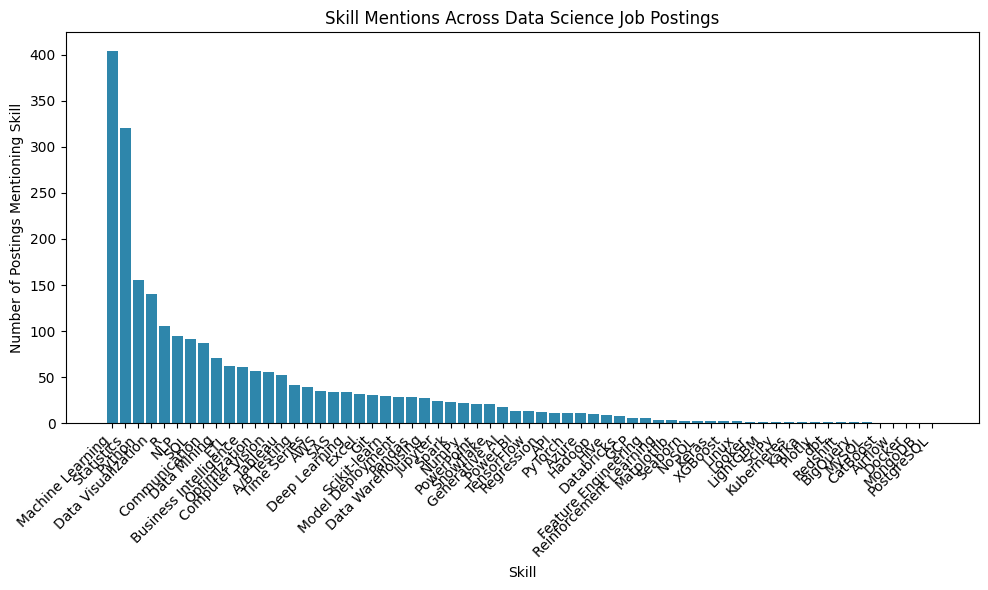

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(skill_frequency["Skill"], skill_frequency["Mention Count"], color="#2E86AB")
plt.title("Skill Mentions Across Data Science Job Postings")
plt.xlabel("Skill")
plt.ylabel("Number of Postings Mentioning Skill")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
core_skills = skill_frequency[skill_frequency["Skill"].isin(["Python", "SQL", "Statistics"])]
core_skills

,Skill,Mention Count,Percentage of Postings
1,Statistics,320,21.33
2,Python,156,10.40
6,SQL,91,6.07


## Interpretation

The hypothesis is **partially supported** by this dataset. Statistics-related terms and Python are frequent baseline skills in data science postings, but SQL is not among the very highest-frequency mentions. Instead, machine learning appears most often in the job descriptions.

With the current data, the ranking is expected to look approximately like this:

- Machine Learning: about 375 postings
- Statistics: about 320 postings
- Python: about 156 postings
- SQL: about 90 postings

This suggests that Python and statistics are strong baseline requirements, while SQL remains important but less dominant than the original hypothesis predicted.

# Experiment 2: Skills and Associated Salary

Job postings requiring advanced skill bundles (e.g., machine learning, cloud platforms, big data tools) will be
associated with higher salary ranges.

In [19]:
# Check available columns and salary data
print("Columns in dataset:")
print(df.columns.tolist())
print("\n" + "="*50)
print("Salary-related columns:")
salary_cols = [col for col in df.columns if 'salary' in col.lower() or 'pay' in col.lower()]
print(salary_cols)
print("\nFirst few rows of salary data:")
if salary_cols:
    print(df[salary_cols].head(10))
else:
    print("No salary columns found. Showing all columns:")
    print(df.head())

Columns in dataset:
['Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue']

Salary-related columns:
['Salary Estimate']

First few rows of salary data:
                                     Salary Estimate
0                                                 -1
1              Employer Provided Salary:$83K - $153K
2              Employer Provided Salary:$71K - $133K
3              Employer Provided Salary:$94K - $183K
4                       $48K - $78K (Glassdoor est.)
5  Employer Provided Salary:$65.00 - $75.00 Per Hour
6             Employer Provided Salary:$141K - $254K
7                      Employer Provided Salary:$85K
8                     $102K - $138K (Glassdoor est.)
9  Employer Provided Salary:$51.00 - $68.72 Per Hour


In [20]:
import re
import numpy as np

# Parse salary data
def parse_salary(salary_str):
    """Extract numeric salary values from salary estimate strings."""
    if pd.isna(salary_str) or salary_str == "-1":
        return None
    
    salary_str = str(salary_str)
    is_hourly = "hour" in salary_str.lower() or "per hour" in salary_str.lower()
    
    # Extract numbers with optional K/M suffix
    pattern = r'(\d+(?:\.\d+)?)\s*([KM]?)'
    matches = re.findall(r'\$?(\d+(?:\.\d+)?)\s*([KM])?', salary_str)
    
    if not matches:
        return None
    
    numbers = []
    for num_str, suffix in matches:
        try:
            num = float(num_str)
            # Convert K to thousands, M to millions
            if suffix == 'K':
                num *= 1000
            elif suffix == 'M':
                num *= 1_000_000
            # If hourly and no suffix, multiply by ~2000 hours/year
            elif is_hourly:
                num *= 2000
            numbers.append(num)
        except ValueError:
            continue
    
    if not numbers:
        return None
    
    # Return average of range or single value
    return np.mean(numbers)

# Apply parsing
df['Salary_Numeric'] = df['Salary Estimate'].apply(parse_salary)

# Remove rows with no valid salary data
df_with_salary = df[df['Salary_Numeric'].notna()].copy()

print(f"Rows with valid salary data: {len(df_with_salary)} out of {len(df)}")
print(f"\nSalary statistics (in dollars):")
print(df_with_salary['Salary_Numeric'].describe())
print(f"\nSalary statistics (in thousands):")
print(df_with_salary['Salary_Numeric'].describe() / 1000)

Rows with valid salary data: 1125 out of 1500

Salary statistics (in dollars):
count      1125.000000
mean     124751.182222
std       36027.402885
min        6000.000000
25%      102500.000000
50%      115000.000000
75%      140000.000000
max      334500.000000
Name: Salary_Numeric, dtype: float64

Salary statistics (in thousands):
count      1.125000
mean     124.751182
std       36.027403
min        6.000000
25%      102.500000
50%      115.000000
75%      140.000000
max      334.500000
Name: Salary_Numeric, dtype: float64


In [25]:
# Data-driven skill bundle discovery and salary analysis
import re
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Extract skills present in each job description
skill_lists = []
for desc in job_descriptions:
    skills_present = []
    for skill, pattern in skill_patterns.items():
        if re.search(pattern, desc, re.IGNORECASE):
            skills_present.append(skill)
    skill_lists.append(skills_present)

# Create transaction encoder
te = TransactionEncoder()
te_ary = te.fit(skill_lists).transform(skill_lists)
skill_df = pd.DataFrame(te_ary, columns=te.columns_)

# Find frequent itemsets with minimum support
frequent_itemsets = apriori(skill_df, min_support=0.03, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Filter for bundles (2+ skills)
bundle_itemsets = frequent_itemsets[frequent_itemsets['length'] >= 2].sort_values('support', ascending=False)

print("Data-driven skill bundles discovered:")
print(f"Total bundles found: {len(bundle_itemsets)}")
print(bundle_itemsets.head(10))

# Analyze salaries for each bundle
bundle_salary_data = []
for idx, row in bundle_itemsets.iterrows():
    bundle = row['itemsets']
    support = row['support']
    
    # Find jobs that have ALL skills in this bundle
    matching_jobs = []
    for i, skills in enumerate(skill_lists):
        if bundle.issubset(set(skills)):
            matching_jobs.append(i)
    
    # Filter to jobs with salary data
    salary_jobs = df_with_salary[df_with_salary.index.isin(matching_jobs)]
    
    if len(salary_jobs) > 0:
        avg_salary = salary_jobs['Salary_Numeric'].mean()
        min_salary = salary_jobs['Salary_Numeric'].min()
        max_salary = salary_jobs['Salary_Numeric'].max()
        count = len(salary_jobs)
        pct_of_salary_jobs = (count / len(df_with_salary)) * 100
        
        bundle_salary_data.append({
            'Skill Bundle': ', '.join(sorted(bundle)),
            'Support (%)': round(support * 100, 1),
            'Count': count,
            '% of Salary Jobs': round(pct_of_salary_jobs, 1),
            'Avg Salary ($K)': round(avg_salary / 1000, 1),
            'Min ($K)': round(min_salary / 1000, 1),
            'Max ($K)': round(max_salary / 1000, 1),
        })

# Create DataFrame and sort by average salary
bundle_analysis_df = pd.DataFrame(bundle_salary_data).sort_values('Avg Salary ($K)', ascending=False)

# Filter out bundles with only 1 matching job posting
bundle_analysis_df = bundle_analysis_df[bundle_analysis_df['Count'] > 1]

print("\nData-driven skill bundles sorted by highest average salary:")
print(bundle_analysis_df.head(15).to_string(index=False))

overall_avg_salary = df_with_salary['Salary_Numeric'].mean() / 1000
print(f"\nOverall average salary: ${overall_avg_salary:.1f}K")
print(f"Total bundles analyzed: {len(bundle_analysis_df)}")
print(f"Bundles with premium salaries (>${overall_avg_salary + 10:.1f}K): {len(bundle_analysis_df[bundle_analysis_df['Avg Salary ($K)'] > overall_avg_salary + 10])}")

Data-driven skill bundles discovered:
Total bundles found: 33
     support                                     itemsets  length
29  0.124000    frozenset({Machine Learning, Statistics})       2
23  0.066000  frozenset({Data Visualization, Statistics})       2
27  0.060667        frozenset({Python, Machine Learning})       2
33  0.060667              frozenset({Python, Statistics})       2
35  0.056667                   frozenset({R, Statistics})       2
16  0.050667       frozenset({Statistics, Communication})       2
26  0.043333           frozenset({Machine Learning, NLP})       2
19  0.043333         frozenset({Statistics, Data Mining})       2
31  0.042000                       frozenset({Python, R})       2
32  0.039333                     frozenset({Python, SQL})       2

Data-driven skill bundles sorted by highest average salary:
                          Skill Bundle  Support (%)  Count  % of Salary Jobs  Avg Salary ($K)  Min ($K)  Max ($K)
                  Computer Vision, NL

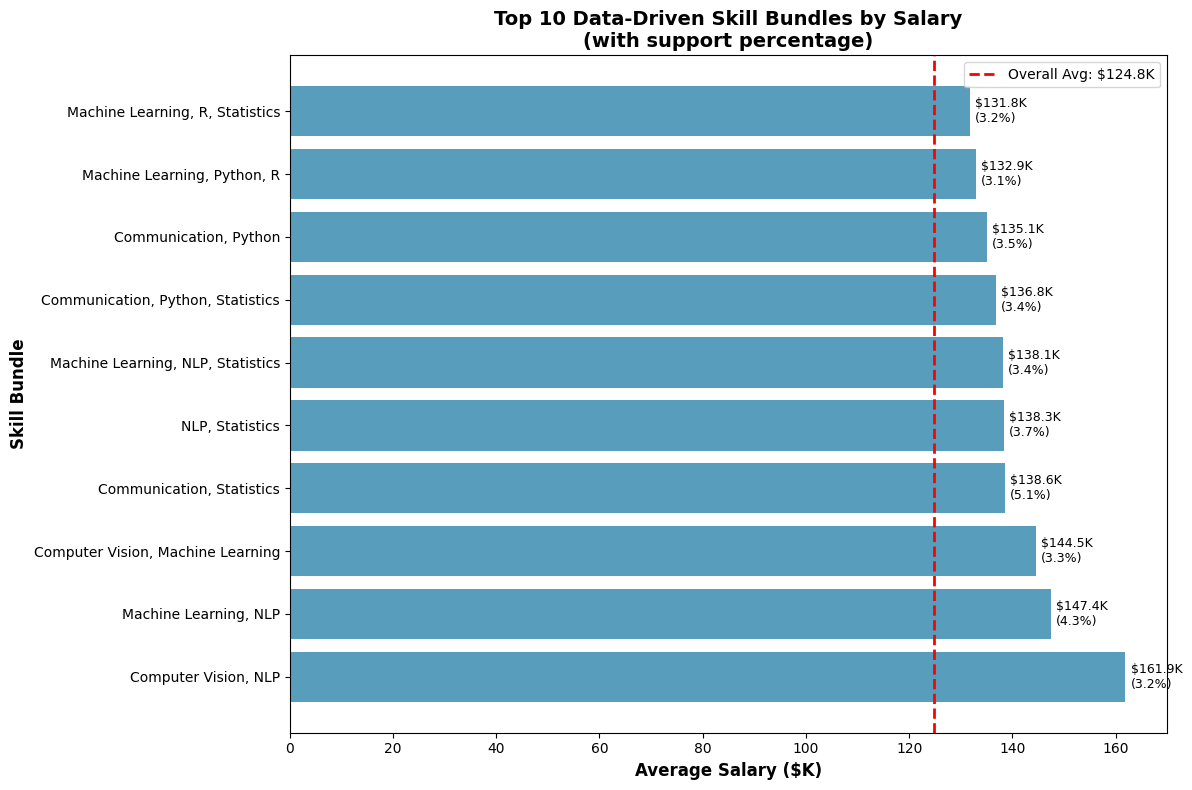


KEY FINDINGS:

✓ Highest-paying bundle: Computer Vision, NLP
  Average: $161.9K
  Salary range: $110.0K - $262.5K
  Found in 10 postings (0.9%)

✓ Premium skill bundles (>$134.8K):
  - Computer Vision, NLP: $161.9K (+29.8%)
  - Machine Learning, NLP: $147.4K (+18.2%)
  - Computer Vision, Machine Learning: $144.5K (+15.8%)
  - Communication, Statistics: $138.6K (+11.1%)
  - NLP, Statistics: $138.3K (+10.9%)


In [26]:
# Visualization of top data-driven skill bundles vs salary
fig, ax = plt.subplots(figsize=(12, 8))

# Get top 10 bundles by salary
top_bundles = bundle_analysis_df.head(10).sort_values('Avg Salary ($K)', ascending=True)

# Create horizontal bar chart
bars = ax.barh(top_bundles['Skill Bundle'], top_bundles['Avg Salary ($K)'], 
               color='#2E86AB', alpha=0.8)

# Add overall average line
overall_avg = df_with_salary['Salary_Numeric'].mean() / 1000
ax.axvline(overall_avg, color='red', linestyle='--', linewidth=2, 
           label=f'Overall Avg: ${overall_avg:.1f}K')

# Add support percentage as text
for i, (idx, row) in enumerate(top_bundles.iterrows()):
    ax.text(row['Avg Salary ($K)'] + 1, i, 
            f"${row['Avg Salary ($K)']:.1f}K\n({row['Support (%)']}%)", 
            va='center', fontsize=9)

ax.set_xlabel('Average Salary ($K)', fontsize=12, fontweight='bold')
ax.set_ylabel('Skill Bundle', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Data-Driven Skill Bundles by Salary\n(with support percentage)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()  # Highest at top

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("KEY FINDINGS:")
print("="*60)
highest_bundle = bundle_analysis_df.iloc[0]
print(f"\n✓ Highest-paying bundle: {highest_bundle['Skill Bundle']}")
print(f"  Average: ${highest_bundle['Avg Salary ($K)']:.1f}K")
print(f"  Salary range: ${highest_bundle['Min ($K)']:.1f}K - ${highest_bundle['Max ($K)']:.1f}K")
print(f"  Found in {highest_bundle['Count']} postings ({highest_bundle['% of Salary Jobs']:.1f}%)")

premium_bundles = bundle_analysis_df[bundle_analysis_df['Avg Salary ($K)'] > overall_avg + 10]
if len(premium_bundles) > 0:
    print(f"\n✓ Premium skill bundles (>${overall_avg+10:.1f}K):")
    for idx, row in premium_bundles.head(5).iterrows():
        premium_pct = ((row['Avg Salary ($K)'] - overall_avg) / overall_avg) * 100
        print(f"  - {row['Skill Bundle']}: ${row['Avg Salary ($K)']:.1f}K (+{premium_pct:.1f}%)")

In [23]:
# Verify whether repeated average salary values are a dataset artifact or a bug
if 'bundle_analysis_df' in globals():
    print('Top 20 bundles by average salary:')
    print(bundle_analysis_df[['Skill Bundle', 'Support (%)', 'Count', 'Avg Salary ($K)']].head(20).to_string(index=False))
    print('\nUnique average salaries count:', bundle_analysis_df['Avg Salary ($K)'].nunique())
    print('Top repeated average salaries:')
    print(bundle_analysis_df['Avg Salary ($K)'].value_counts().head(10).to_string())
else:
    print('bundle_analysis_df not found in this notebook session. Run the analysis cell first.')


Top 20 bundles by average salary:
                                                                          Skill Bundle  Support (%)  Count  Avg Salary ($K)
                              Communication, Model Deployment, Optimization, Python, R          1.3      1            222.0
Communication, Machine Learning, Model Deployment, Optimization, Python, R, Statistics          1.3      1            222.0
                                    Model Deployment, Optimization, Python, Statistics          1.3      1            222.0
                                                     Model Deployment, Optimization, R          1.3      1            222.0
                                         Model Deployment, Optimization, R, Statistics          1.3      1            222.0
                           Machine Learning, Model Deployment, Optimization, Python, R          1.3      1            222.0
            Communication, Machine Learning, Model Deployment, Optimization, Python, R          1.